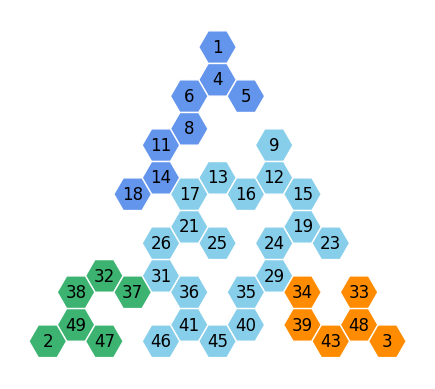

{'to_1': {1, 4, 5, 6, 8, 11, 14, 18}, 'to_2': {32, 49, 2, 37, 38, 47}, 'to_3': {48, 33, 34, 3, 39, 43}, 'loop_12': {25, 26, 21}, 'loop_13': {9, 12, 13, 15, 16, 19, 23, 24}, 'loop_23': {35, 36, 40, 41, 45, 46}, 'choice_point_1': {17}, 'choice_point_2': {31}, 'choice_point_3': {29}}


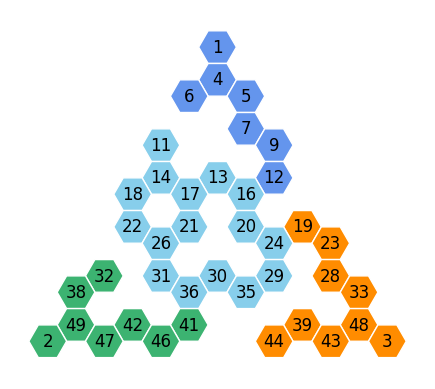

{'to_1': {1, 4, 5, 6, 7, 9, 12}, 'to_2': {32, 2, 38, 41, 42, 46, 47, 49}, 'to_3': {33, 3, 39, 43, 44, 48, 19, 23, 28}, 'loop_12': {11, 13, 14, 17, 18, 21, 22, 26, 31}, 'loop_13': set(), 'loop_23': set(), 'choice_point_1': {16, 24}, 'choice_point_2': {24, 36}, 'choice_point_3': {24}}


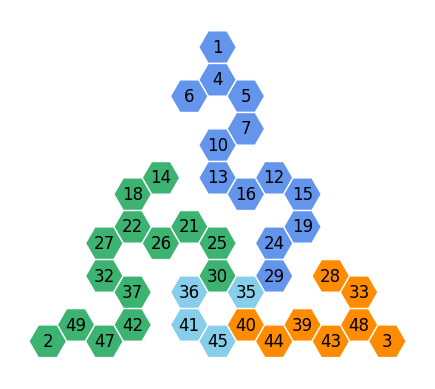

{'to_1': {1, 4, 5, 6, 7, 10, 12, 13, 15, 16, 19, 24, 29}, 'to_2': {32, 2, 37, 42, 14, 47, 49, 18, 21, 22, 25, 26, 27, 30}, 'to_3': {33, 3, 39, 40, 43, 44, 48, 28}, 'loop_12': set(), 'loop_13': set(), 'loop_23': {41, 36, 45}, 'choice_point_1': {35}, 'choice_point_2': {35}, 'choice_point_3': {35}}
{1, 35, 4, 5, 7, 10, 12, 13, 15, 16, 19, 24, 29}
{32, 2, 35, 37, 42, 47, 49, 21, 22, 25, 26, 27, 30}
{3, 35, 39, 40, 43, 44, 48}


In [1]:
import pandas as pd
import sys
sys.path.append("..") # Use sys to add the parent directory (where src/hexmaze lives) to the path

from src.hexmaze import divide_into_thirds, plot_hex_maze, get_critical_choice_points, classify_hexes_by_region, divide_into_thirds_from_port, get_path_independent_hexes_to_port

thirds_colors = ['cornflowerblue', 'mediumseagreen', 'darkorange']

# Load the barrier sequence database and grab 2 mazes that differ by one barrier
barrier_sequence_database = pd.read_pickle('../Barrier_Sequence_Databases/barrier_sequence_database.pkl')
sequence = barrier_sequence_database.iloc[7]['barrier_sequence'] #7, 13
maze1 = sequence[0]
maze_thirds = divide_into_thirds(maze1)
plot_hex_maze(maze1, highlight_hexes=maze_thirds, highlight_colors=thirds_colors, show_barriers=False, show_choice_points=False)
cp1 = get_critical_choice_points(maze1)
hex_types = classify_hexes_by_region(maze1)
print(hex_types)

maze = '8,10,15,25,27,34,37,40,45'
maze_thirds = divide_into_thirds(maze)
plot_hex_maze(maze, highlight_hexes=maze_thirds, highlight_colors=thirds_colors, show_barriers=False, show_choice_points=False)
cp = get_critical_choice_points(maze)
hex_types = classify_hexes_by_region(maze)
print(hex_types)


maze = '8,9,11,17,20,23,31,34,38,46'
maze_thirds = divide_into_thirds(maze)
plot_hex_maze(maze, highlight_hexes=maze_thirds, highlight_colors=thirds_colors, show_barriers=False, show_choice_points=False)
cp = get_critical_choice_points(maze)
hex_types = classify_hexes_by_region(maze)
print(hex_types)
print(get_path_independent_hexes_to_port(maze,1))
print(get_path_independent_hexes_to_port(maze,2))
print(get_path_independent_hexes_to_port(maze,3))


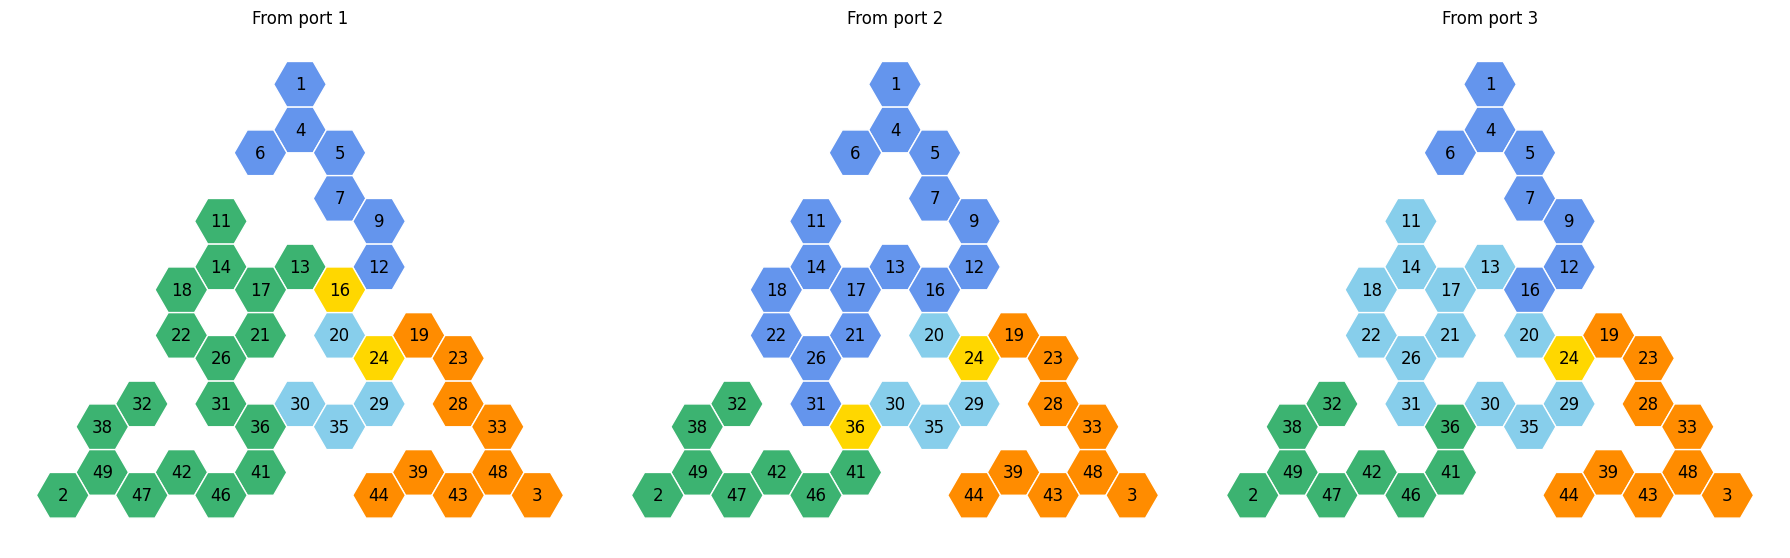

In [3]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

maze = '8,10,15,25,27,34,37,40,45'
#maze = '8,9,11,17,20,23,31,34,38,46'
thirds_colors = ['cornflowerblue', 'mediumseagreen', 'darkorange']

for i, port in enumerate([1, 2, 3]):
    thirds = divide_into_thirds_from_port(maze, start_port=port)
    plot_hex_maze(maze, highlight_hexes=thirds, highlight_colors=thirds_colors,
                  show_barriers=False, show_choice_points=True, ax=axes[i])
    axes[i].set_title(f"From port {port}")

plt.tight_layout()
plt.show()
